In [ ]:
#Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report,f1_score

from google.colab import files

In [ ]:
df=pd.read_excel('cleaned_sentiment_dataset.xlsx')
df.head()

,title,rating,body,review_text,cleaned_text,sentiment,review_length,word_count,character_count,unique_word_count,average_word_length,sentence_count,exclamation_count,question_count,hashtag_count,uppercase_word_count,vader_negative_score,vader_neutral_score,vader_positive_score,vader_compound_score
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...,horrible product disappointed overall performa...,Negative,76,10,76,6,8.666667,1,0,0,0,0,0.463,0.537,0.000,-0.7841
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...,camera quality not like megapixel camera quali...,Neutral,61,11,61,6,5.625000,1,0,0,0,0,0.319,0.681,0.000,-0.4956
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt...",overall got mobile launch datebattery must app...,Positive,411,67,411,34,6.513514,3,0,1,0,1,0.076,0.843,0.081,0.1027
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...,big no doesnt work ghz wifi frequency ghz old ...,Negative,394,72,394,35,4.897436,13,0,0,0,2,0.209,0.770,0.021,-0.9162
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...,put money somewhere else not worth buyingfault...,Negative,209,34,209,26,5.214286,4,0,0,0,9,0.235,0.765,0.000,-0.8033


In [ ]:
#Check target larbel distribution
print(df['sentiment'].value_counts())

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64


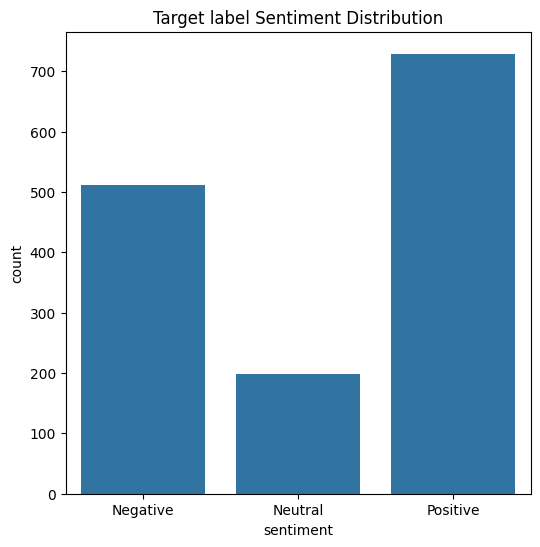

In [ ]:
#Visualize
plt.figure(figsize=(6,6))

sns.countplot(
    data=df,
    x='sentiment'
)

plt.title("Target label Sentiment Distribution")

plt.show()

In [ ]:
#Define x and y for the model building
X=df['cleaned_text']
y=df['sentiment']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=y
                                              )

#EXPERIMENT 1 : TF-IDF
#Cleaned Text
#         ↓
#TF-IDF
#         ↓
#ML Models

In [ ]:
#Applying TF-IDF
tfidf=TfidfVectorizer(
    max_features=3012,
    min_df=2,
    max_df=0.95,
    ngram_range=(1,2),
    sublinear_tf=True
)

X_train_tfidf=tfidf.fit_transform(X_train)

X_test_tfidf=tfidf.transform(X_test)

In [ ]:
#Logistic Regression
logistic_model=LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

#Train the model
logistic_model.fit(X_train_tfidf,y_train)

#predict the model
y_predict_logistic=logistic_model.predict(X_test_tfidf)


In [ ]:
# Logistic model evaluation
print('The precision score is:', precision_score(y_test, y_predict_logistic, average='weighted', zero_division=0))
print('The accuracy score is:', accuracy_score(y_test, y_predict_logistic))
print('The recall_score is:', recall_score(y_test, y_predict_logistic, average='weighted'))
print('The F1 score is:', f1_score(y_test, y_predict_logistic, average='weighted', zero_division=0))

The precision score is: 0.7731256484174363
The accuracy score is: 0.7604166666666666
The recall_score is: 0.7604166666666666
The F1 score is: 0.7661805975667136


In [ ]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB
nb_model=MultinomialNB(
)

nb_model.fit(X_train_tfidf,y_train)

#predict the model
nb_model_pred=nb_model.predict(X_test_tfidf)

In [ ]:
# Evaluation of the model

print('The precision score is:', precision_score(y_test, nb_model_pred, average='weighted', zero_division=0))
print('The accuracy score is:', accuracy_score(y_test, nb_model_pred))
print('The recall_score is:', recall_score(y_test, nb_model_pred, average='weighted'))
print('The F1 score is:', f1_score(y_test, nb_model_pred, average='weighted', zero_division=0))

The precision score is: 0.6623943111846338
The accuracy score is: 0.7604166666666666
The recall_score is: 0.7604166666666666
The F1 score is: 0.701906784971301


In [ ]:
#Linear svm
from sklearn.svm import LinearSVC

svm_model=LinearSVC(
    random_state=42
)

#train the model
svm_model.fit(X_train_tfidf,y_train)

#predict the model
y_pred_svm=svm_model.predict(X_test_tfidf)

In [ ]:
# Evaluation of the model

print('The precision score is:', precision_score(y_test, y_pred_svm, average='weighted', zero_division=0))
print('The accuracy score is:', accuracy_score(y_test, y_pred_svm))
print('The recall_score is:', recall_score(y_test, y_pred_svm, average='weighted'))
print('The F1 score is:', f1_score(y_test, y_pred_svm, average='weighted', zero_division=0))

The precision score is: 0.7679024024568194
The accuracy score is: 0.7951388888888888
The recall_score is: 0.7951388888888888
The F1 score is: 0.7724852242848724


In [ ]:
# Create metrics comparison table
data = {
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_predict_logistic),
        accuracy_score(y_test, nb_model_pred),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_predict_logistic, average='weighted', zero_division=0),
        precision_score(y_test, nb_model_pred, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_predict_logistic, average='weighted', zero_division=0),
        recall_score(y_test, nb_model_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, y_predict_logistic, average='weighted', zero_division=0),
        f1_score(y_test, nb_model_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)
    ]
}

df_comparison = pd.DataFrame(data)

# Display table
print("Model Comparison Table ")
display(df_comparison)

# Declare best model
best_model = df_comparison.loc[df_comparison['F1 Score'].idxmax(), 'Model']
print(f"\nBest Model without engineered features: {best_model}")

Model Comparison Table 


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.760417,0.773126,0.760417,0.766181
1,Multinomial Naive Bayes,0.760417,0.662394,0.760417,0.701907
2,Linear SVM,0.795139,0.767902,0.795139,0.772485



Best Model without engineered features: Linear SVM


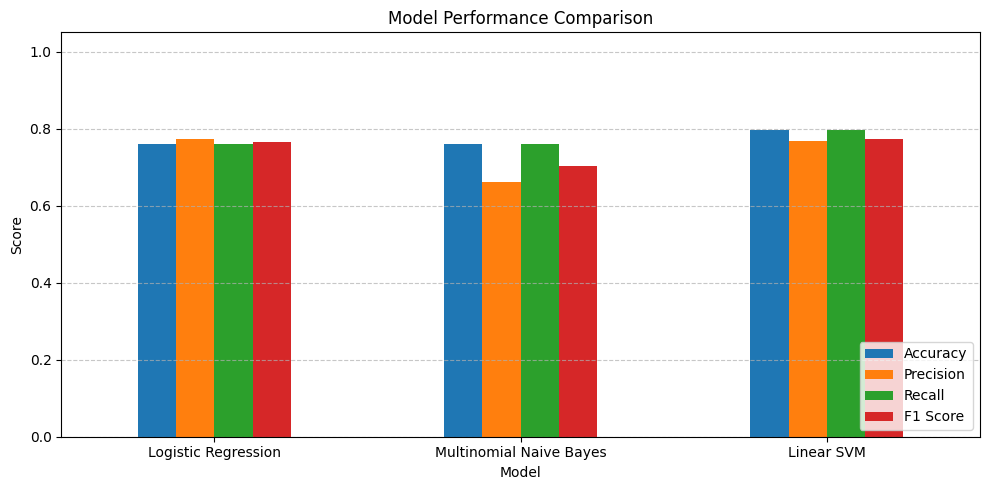

In [ ]:
plot_df = df_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

# Plot bar chart
plot_df.plot(kind="bar", figsize=(10, 5))

# Plot customization
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
#Logistic regression
cr=classification_report(y_test,y_predict_logistic)
print('The classification report for the logistic model is:',cr)

The classification report for the logistic model is:               precision    recall  f1-score   support

    Negative       0.81      0.81      0.81       102
     Neutral       0.34      0.40      0.37        40
    Positive       0.86      0.82      0.84       146

    accuracy                           0.76       288
   macro avg       0.67      0.68      0.67       288
weighted avg       0.77      0.76      0.77       288



In [ ]:
cm=confusion_matrix(y_test,y_predict_logistic)
print('confusion matrix is:\n',cm)

confusion matrix is:
 [[ 83  13   6]
 [ 11  16  13]
 [  8  18 120]]


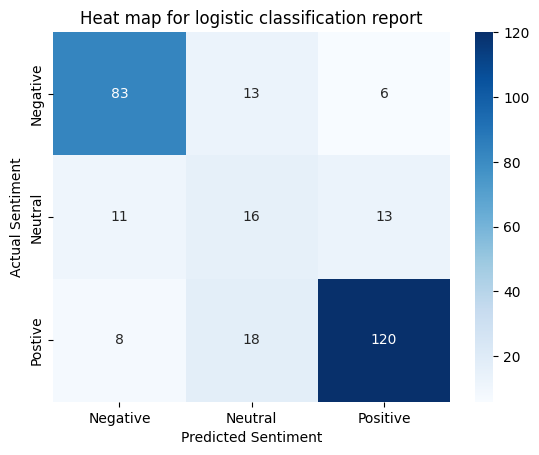

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Postive']
)
plt.title('Heat map for logistic classification report')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

In [ ]:
#SVM
cr1=classification_report(y_test,y_pred_svm)
print('The classification report for linearsvm is\n:',cr1)

The classification report for linearsvm is
:               precision    recall  f1-score   support

    Negative       0.78      0.86      0.82       102
     Neutral       0.47      0.20      0.28        40
    Positive       0.84      0.91      0.88       146

    accuracy                           0.80       288
   macro avg       0.70      0.66      0.66       288
weighted avg       0.77      0.80      0.77       288



In [ ]:
cm1=confusion_matrix(y_test,y_pred_svm)
print('The confusion matrix is \n:',cm1)

The confusion matrix is 
: [[ 88   5   9]
 [ 16   8  16]
 [  9   4 133]]


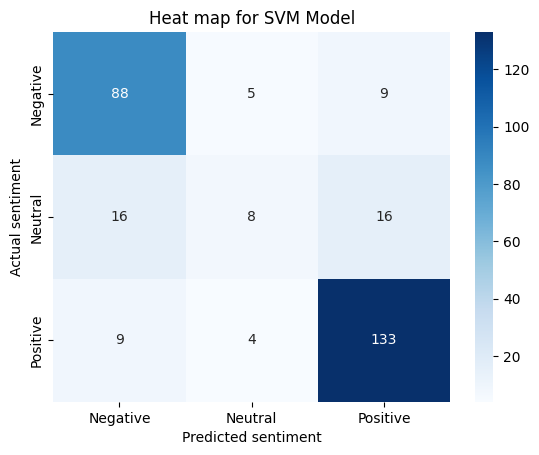

In [ ]:
sns.heatmap(
    cm1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)
plt.title('Heat map for SVM Model')
plt.ylabel('Actual sentiment')
plt.xlabel('Predicted sentiment')
plt.show()

#EXPERIMENT 2 — TF-IDF +Eng Features
#Cleaned Text
#     ↓
#TF-IDF
#    ↓
#ML Models

In [ ]:
engineered_features = [
    'review_length',
    'word_count',
    'unique_word_count',
    'average_word_length',
    'sentence_count',
    'exclamation_count',
    'question_count',
    'hashtag_count',
    'vader_negative_score',
    'vader_neutral_score',
    'vader_positive_score',
    'vader_compound_score'
]
df[engineered_features].head()

,review_length,word_count,unique_word_count,average_word_length,sentence_count,exclamation_count,question_count,hashtag_count,vader_negative_score,vader_neutral_score,vader_positive_score,vader_compound_score
0,76,10,6,8.666667,1,0,0,0,0.463,0.537,0.000,-0.7841
1,61,11,6,5.625000,1,0,0,0,0.319,0.681,0.000,-0.4956
2,411,67,34,6.513514,3,0,1,0,0.076,0.843,0.081,0.1027
3,394,72,35,4.897436,13,0,0,0,0.209,0.770,0.021,-0.9162
4,209,34,26,5.214286,4,0,0,0,0.235,0.765,0.000,-0.8033


In [ ]:
#split the features
X_text=df['cleaned_text']
X_eng=df[engineered_features]
y=df['sentiment']

In [ ]:
X_text_train,X_text_test,X_eng_train,X_eng_test,y_train,y_test=train_test_split(X_text,
                                                                                X_eng,
                                                                                y,
                                                                                test_size=0.2,
                                                                                random_state=42,
                                                                                stratify=y)

In [ ]:
#Here observe that there are different scaled values in the engineered features so we want to scale the features

In [ ]:
scaler=StandardScaler()

X_eng_train_scaled=scaler.fit_transform(X_eng_train)
X_eng_test_scaled=scaler.transform(X_eng_test)

In [ ]:
#create vectorizer for cleaned text
tfidf1=TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1,2),
    sublinear_tf=True
)

X_train_tfidf=tfidf1.fit_transform(X_text_train)
X_test_tfidf=tfidf1.transform(X_text_test)

In [ ]:
#combine the TF-IDF and engineered_features

X_train_combined=hstack([
    X_train_tfidf,
    X_eng_train_scaled
])

X_test_combined=hstack([
    X_test_tfidf,
    X_eng_test_scaled
])

In [ ]:
#Logistic regression
from sklearn.linear_model import LogisticRegression

lr_model_eng=LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr_model_eng.fit(X_train_combined,y_train)

#Predict the model
lr_y_pred=lr_model_eng.predict(X_test_combined)


In [ ]:
#Model evaluation

print('The precision score is:', precision_score(y_test, lr_y_pred, average='weighted', zero_division=0))
print('The accuracy score is:', accuracy_score(y_test, lr_y_pred))
print('The recall_score is:', recall_score(y_test, lr_y_pred, average='weighted'))
print('The F1 score is:', f1_score(y_test, lr_y_pred, average='weighted', zero_division=0))

The precision score is: 0.7236863313990973
The accuracy score is: 0.7083333333333334
The recall_score is: 0.7083333333333334
The F1 score is: 0.7155097965982568


In [ ]:
#simple linear SVM
svm_model1=LinearSVC(
    max_iter=5000,
    random_state=42
)

svm_model1.fit(X_train_combined,y_train)

#Predict the model
y_pred_lsvm=svm_model1.predict(X_test_combined)

In [ ]:
#Model evaluation

print('The precision score is:', precision_score(y_test, y_pred_lsvm, average='weighted', zero_division=0))
print('The accuracy score is:', accuracy_score(y_test, y_pred_lsvm))
print('The recall_score is:', recall_score(y_test, y_pred_lsvm, average='weighted'))
print('The F1 score is:', f1_score(y_test, y_pred_lsvm, average='weighted', zero_division=0))

The precision score is: 0.7476217859096287
The accuracy score is: 0.7743055555555556
The recall_score is: 0.7743055555555556
The F1 score is: 0.7532324347028813


In [ ]:
# Create metrics comparison table
data = {
    'Model': ['Logistic Regression','Linear SVM'],
    'Accuracy': [
        accuracy_score(y_test, lr_y_pred),
        accuracy_score(y_test, y_pred_lsvm)
    ],
    'Precision': [
        precision_score(y_test, lr_y_pred, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_lsvm, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, lr_y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_lsvm, average='weighted', zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, lr_y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_lsvm, average='weighted', zero_division=0)
    ]
}

df_comparison = pd.DataFrame(data)

# Display table
print("Model Comparison Table with Eng Features")
display(df_comparison)

# Declare best model
best_model = df_comparison.loc[df_comparison['F1 Score'].idxmax(), 'Model']
print(f"\nBest Model with engineered features: {best_model}")

Model Comparison Table with Eng Features


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.708333,0.723686,0.708333,0.715510
1,Linear SVM,0.774306,0.747622,0.774306,0.753232



Best Model with engineered features: Linear SVM


In [ ]:
#Linear SVM
cm_svm=confusion_matrix(y_test,y_pred_lsvm)
cm_svm

array([[ 85,   4,  13],
       [ 17,   8,  15],
       [ 10,   6, 130]])

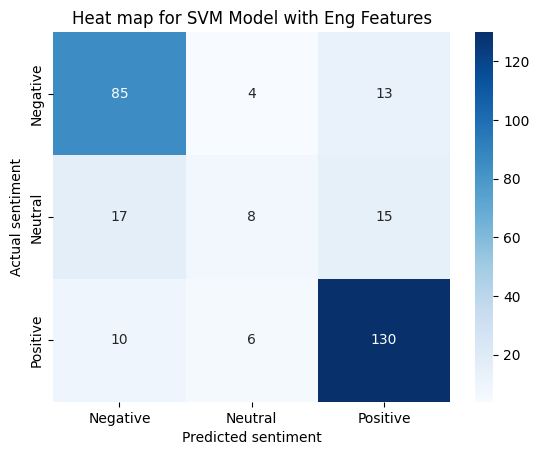

In [ ]:
sns.heatmap(
    cm_svm,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)
plt.title('Heat map for SVM Model with Eng Features')
plt.ylabel('Actual sentiment')
plt.xlabel('Predicted sentiment')
plt.show()


#EXPERIMENT 3 — Word2vec
#Cleaned Text
#    ↓
#Word2vec
#    ↓
#ML Models

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 20.2 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier


import numpy as np
from sklearn.preprocessing import MinMaxScaler


In [ ]:
X=df['cleaned_text']
y=df['sentiment']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=y
                                              )

In [ ]:
#Apply the word2vec for the cleaned text

sentences = [text.split() for text in x_train]

word2vec_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
def review_to_vector(review):
    vectors = [
        word2vec_model.wv[word]
        for word in review.split()
        if word in word2vec_model.wv
    ]

    if not vectors:
        return np.zeros(word2vec_model.vector_size)

    return np.mean(vectors, axis=0)

In [ ]:
#Apply to the train and test data
x_train_w2v = np.array([review_to_vector(review) for review in x_train])
x_test_w2v = np.array([review_to_vector(review) for review in x_test])

print(x_train_w2v.shape)
print(x_test_w2v.shape)

(1152, 100)
(288, 100)


In [ ]:
scaler=MinMaxScaler()

x_train_w2v_scaled=scaler.fit_transform(x_train_w2v)
x_test_w2v_scaled=scaler.transform(x_test_w2v)

In [ ]:
#Logistic regression
from sklearn.linear_model import LogisticRegression

lr_model_w2v=LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model_w2v.fit(x_train_w2v_scaled,y_train)

#Predict the model
lr_y_pred_w2v=lr_model_w2v.predict(x_test_w2v_scaled)

In [ ]:
#Evaluation of the logistic model
print('The precision score is:', precision_score(y_test, lr_y_pred_w2v, average='weighted', zero_division=0))
print('The accuracy score is:', accuracy_score(y_test, lr_y_pred_w2v))
print('The recall_score is:', recall_score(y_test, lr_y_pred_w2v, average='weighted'))
print('The F1 score is:', f1_score(y_test, lr_y_pred_w2v, average='weighted', zero_division=0))

The precision score is: 0.682887148938194
The accuracy score is: 0.6597222222222222
The recall_score is: 0.6597222222222222
The F1 score is: 0.6696796484702622


In [ ]:
#Linear svm
from sklearn.svm import LinearSVC

svm_model_w2v=LinearSVC(
    max_iter=5000,
    random_state=42
)

svm_model_w2v.fit(x_train_w2v_scaled,y_train)

#predict the model
y_pred_svm_w2v=svm_model_w2v.predict(x_test_w2v_scaled)

In [ ]:
#Evaluation metrix
print('The precision score is:', precision_score(y_test, y_pred_svm_w2v, average='weighted', zero_division=0))
print('The accuracy score is:', accuracy_score(y_test, y_pred_svm_w2v))
print('The recall_score is:', recall_score(y_test, y_pred_svm_w2v, average='weighted'))
print('The F1 score is:', f1_score(y_test, y_pred_svm_w2v, average='weighted', zero_division=0))

The precision score is: 0.7813487608117099
The accuracy score is: 0.7465277777777778
The recall_score is: 0.7465277777777778
The F1 score is: 0.6958485261931455


In [ ]:
#Random Forest
rf_model_w2v=RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model_w2v.fit(x_train_w2v_scaled,y_train)

#predict the model
y_pred_rf_w2v=rf_model_w2v.predict(x_test_w2v_scaled)

In [ ]:
#Evaluation of the matrix
print('The precision score is:', precision_score(y_test, y_pred_rf_w2v, average='weighted', zero_division=0))
print('The accuracy score is:', accuracy_score(y_test, y_pred_rf_w2v))
print('The recall_score is:', recall_score(y_test, y_pred_rf_w2v, average='weighted'))
print('The F1 score is:', f1_score(y_test, y_pred_rf_w2v, average='weighted'))

The precision score is: 0.6283140257987819
The accuracy score is: 0.6805555555555556
The recall_score is: 0.6805555555555556
The F1 score is: 0.648988036217576


In [ ]:
#Comparision of the models

data={
    'Model':['Logistic Regression','Linear SVM','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test,lr_y_pred_w2v),
        accuracy_score(y_test,y_pred_svm_w2v),
        accuracy_score(y_test,y_pred_rf_w2v)
    ],
    'Precision':[
        precision_score(y_test,lr_y_pred_w2v,average='weighted',zero_division=0),
        precision_score(y_test,y_pred_svm_w2v,average='weighted',zero_division=0),
        precision_score(y_test,y_pred_rf_w2v,average='weighted',zero_division=0)
    ],
    'Recall':[
        recall_score(y_test,lr_y_pred_w2v,average='weighted',zero_division=0),
        recall_score(y_test,y_pred_svm_w2v,average='weighted',zero_division=0),
        recall_score(y_test,y_pred_rf_w2v,average='weighted',zero_division=0),
    ],
    'F1 Score':[
        f1_score(y_test,lr_y_pred_w2v,average='weighted',zero_division=0),
        f1_score(y_test,y_pred_svm_w2v,average='weighted',zero_division=0),
        f1_score(y_test,y_pred_rf_w2v,average='weighted',zero_division=0)
    ]
}

df_comparison=pd.DataFrame(data)

#Display the data
print('Model Comparison Table with Word2Vec')
display(df_comparison)

#declare the best model

best_model=df_comparison.loc[df_comparison['F1 Score'].idxmax(),'Model']
print(f'\nBest Model with Word2Vec: {best_model}')

Model Comparison Table with Word2Vec


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.659722,0.682887,0.659722,0.669680
1,Linear SVM,0.746528,0.781349,0.746528,0.695849
2,Random Forest,0.680556,0.628314,0.680556,0.648988



Best Model with Word2Vec: Linear SVM


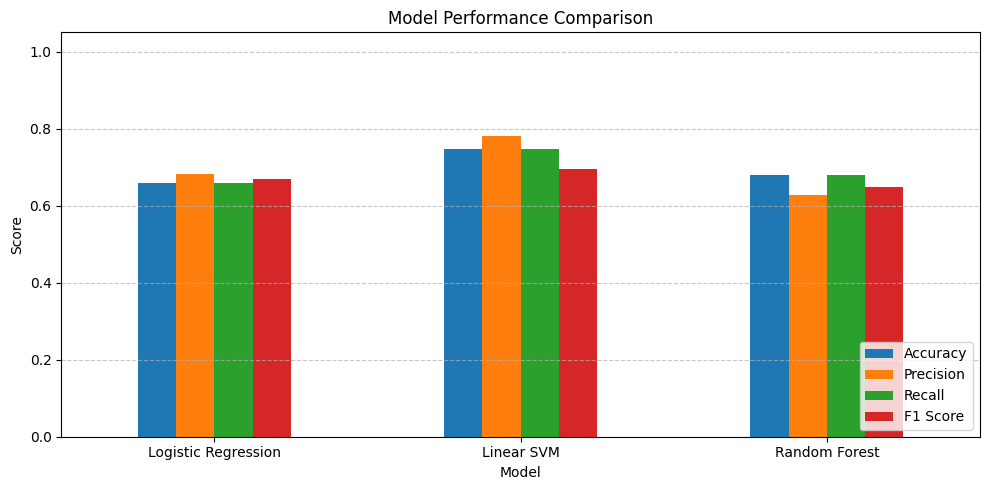

In [ ]:
#plot the comparion

plot_df=df_comparison.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']]

plot_df.plot(kind="bar",figsize=(10,5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#confusion matrix for the logistic

cm=confusion_matrix(y_test,lr_y_pred_w2v)
cm

array([[ 76,  17,   9],
       [ 14,   9,  17],
       [ 17,  24, 105]])

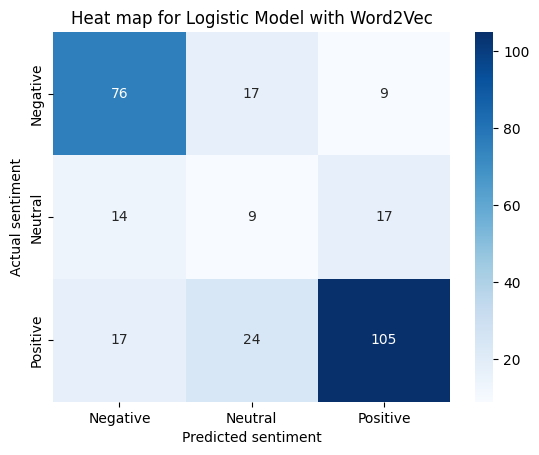

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)
plt.title('Heat map for Logistic Model with Word2Vec')
plt.ylabel('Actual sentiment')
plt.xlabel('Predicted sentiment')
plt.show()

#EXPERIMENT 4 — Word2vec
#Cleaned Text
#    ↓
#Word2vec
#    ↓
#DL Models

In [ ]:
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,LSTM,Dense,Masking,Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [ ]:
X=df['cleaned_text']
y=df['sentiment']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=y
                                              )
le=LabelEncoder()

y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [ ]:
#create word2vec object
sentences=[text.split() for text in X_train]
word2vec_modeld=Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
def review_to_vector(review):
  vectors=[
      word2vec_modeld.wv[word]
      for word in review.split()
      if word in word2vec_modeld.wv
  ]

  if not vectors:
    return np.empty((0,100))

  return np.array(vectors)

In [ ]:
#Apply to the train,test data
X_train_w2=[review_to_vector(review) for review in X_train]
X_test_w2=[review_to_vector(review) for review in X_test]

In [ ]:
#check the distribution of the sequence length
lenghts=[len(seq)for seq in X_train_w2]
np.percentile(lenghts,[50,60,75,90,95,99])

array([ 27.,  31.,  37.,  51.,  68., 107.])

In [ ]:
max_len=68
vector_size=100

In [ ]:
def pad_sequences(sequences,max_len,vector_size):
  padded=np.zeros((len(sequences),max_len,vector_size))

  for i,seq in enumerate(sequences):
    length=min(len(seq),max_len)
    padded[i,:length,:]=seq[:length]
  return padded

In [ ]:
#pad training data
X_train_w2v_padded=pad_sequences(X_train_w2,max_len,vector_size)

#pad test data
X_test_w2v_padded=pad_sequences(X_test_w2,max_len,vector_size)

In [ ]:
#Building RNN model
rnn_model = Sequential([
    Masking(mask_value=0.0, input_shape=(max_len, vector_size)),
    SimpleRNN(64, activation='tanh'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_rnn=rnn_model.fit(
    X_train_w2v_padded,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]

    )

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.4788 - loss: 1.0601 - val_accuracy: 0.5022 - val_loss: 0.9820
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.4821 - loss: 1.0442 - val_accuracy: 0.5325 - val_loss: 1.0025
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4832 - loss: 1.0318 - val_accuracy: 0.4978 - val_loss: 0.9755
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.4669 - loss: 1.0195 - val_accuracy: 0.5238 - val_loss: 0.9850
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.4799 - loss: 1.0212 - val_accuracy: 0.4719 - val_loss: 0.9917
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.4864 - loss: 1.0191 - val_accuracy: 0.4762 - val_loss: 1.0133
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.4625 - loss: 1.0331 - val_accuracy: 0.5325 - val_loss: 0.9663


In [ ]:
#Predict the model
y_pred_rnn=rnn_model.predict(X_test_w2v_padded)
rnn_y_pred=np.argmax(y_pred_rnn,axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [ ]:
print('The accuaracy of RNN is:',accuracy_score(y_test,rnn_y_pred))
print('The precision of RNN is:',precision_score(y_test,rnn_y_pred,average='weighted',zero_division=0))
print('The recall of RNN is:',recall_score(y_test,rnn_y_pred,average='weighted',zero_division=0))
print('The f1 score of RNN is:',f1_score(y_test,rnn_y_pred,average='weighted',zero_division=0))

The accuaracy of RNN is: 0.5173611111111112
The precision of RNN is: 0.5430751864939144
The recall of RNN is: 0.5173611111111112
The f1 score of RNN is: 0.3691694684685339


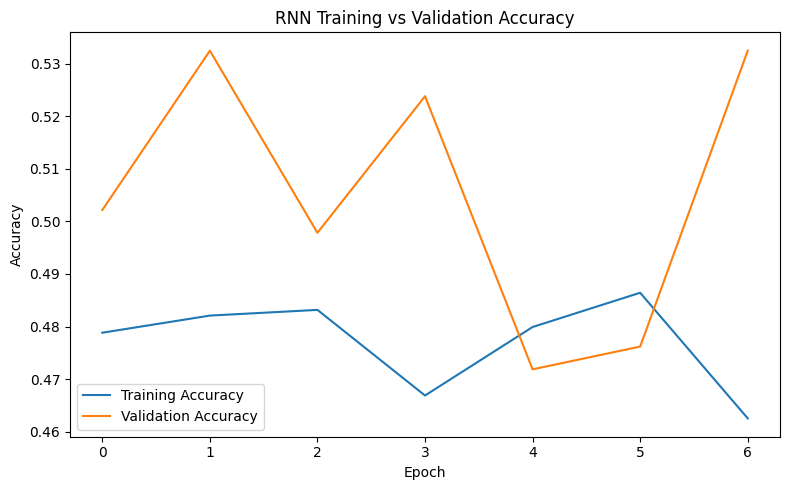

In [ ]:
# RNN Accuracy Curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(
    history_rnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_rnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("RNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
cm=confusion_matrix(y_test,rnn_y_pred)
cm

array([[  4,   0,  98],
       [  0,   0,  40],
       [  1,   0, 145]])

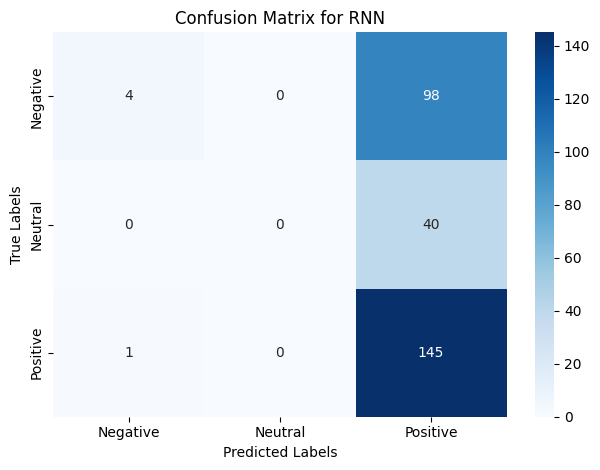

In [ ]:
import seaborn as sns
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)
plt.title('Confusion Matrix for RNN')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()


In [ ]:
#LSTM Model
lstm_model=Sequential([
    Masking(mask_value=0.0,input_shape=(max_len,vector_size)),
    LSTM(64,activation='tanh'),
    Dropout(0.3),
    Dense(3,activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

In [ ]:
early_stoppping=EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

In [ ]:
history_lstm=lstm_model.fit(
    X_train_w2v_padded,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.4864 - loss: 1.0151 - val_accuracy: 0.5281 - val_loss: 0.9724
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.4669 - loss: 1.0089 - val_accuracy: 0.5238 - val_loss: 0.9790
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.4962 - loss: 0.9961 - val_accuracy: 0.5325 - val_loss: 0.9740
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.4929 - loss: 0.9946 - val_accuracy: 0.5281 - val_loss: 0.9722
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.5125 - loss: 0.9889 - val_accuracy: 0.5281 - val_loss: 0.9681


In [ ]:
#Predict the model
y_pred_lstm=lstm_model.predict(X_test_w2v_padded)
lstm_y_pred=np.argmax(y_pred_lstm,axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [ ]:
#Evaluation
print('The Accuarcy of LSTM is :',accuracy_score(y_test,lstm_y_pred))
print('The Precision of LSTM is :',precision_score(y_test,lstm_y_pred,average='weighted',zero_division=0, labels=np.unique(y_test)))
print('The Recall of LSTM is :',recall_score(y_test,lstm_y_pred,average='weighted',zero_division=0, labels=np.unique(y_test)))
print('The F1 Score of LSTM is :',f1_score(y_test,lstm_y_pred,average='weighted',zero_division=0, labels=np.unique(y_test)))

The Accuarcy of LSTM is : 0.5069444444444444
The Precision of LSTM is : 0.25699266975308643
The Recall of LSTM is : 0.5069444444444444
The F1 Score of LSTM is : 0.34107782898105476


In [ ]:
cm=confusion_matrix(
    y_test,
    lstm_y_pred,
)
cm

array([[  0,   0, 102],
       [  0,   0,  40],
       [  0,   0, 146]])

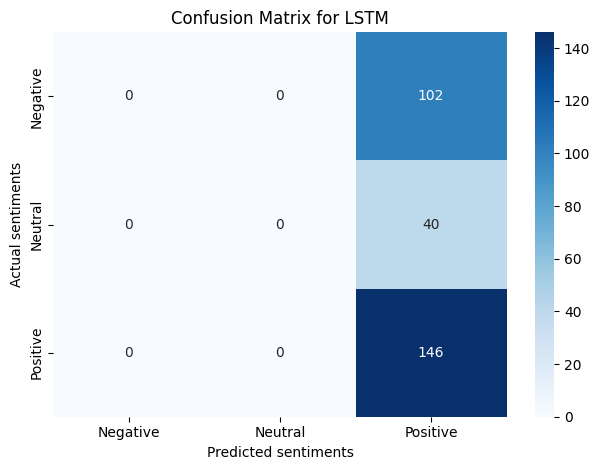

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)
plt.title('Confusion Matrix for LSTM')
plt.xlabel('Predicted sentiments')
plt.ylabel('Actual sentiments')
plt.tight_layout()
plt.show()

In [ ]:
df_comparision_results=pd.DataFrame({
    'Model':['RNN','LSTM'],
    'Accuracy':[accuracy_score(y_test,rnn_y_pred),accuracy_score(y_test,lstm_y_pred)],
    'Precision':[precision_score(y_test,rnn_y_pred,average='weighted',zero_division=0),
                 precision_score(y_test,lstm_y_pred,average='weighted',zero_division=0)],
    'Recall':[recall_score(y_test,rnn_y_pred,average='weighted',zero_division=0),
              recall_score(y_test,lstm_y_pred,average='weighted',zero_division=0)],
    'F1 Score':[f1_score(y_test,rnn_y_pred,average='weighted',zero_division=0),
                f1_score(y_test,lstm_y_pred,average='weighted',zero_division=0)]
})

display(df_comparision_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,RNN,0.517361,0.543075,0.517361,0.369169
1,LSTM,0.506944,0.256993,0.506944,0.341078


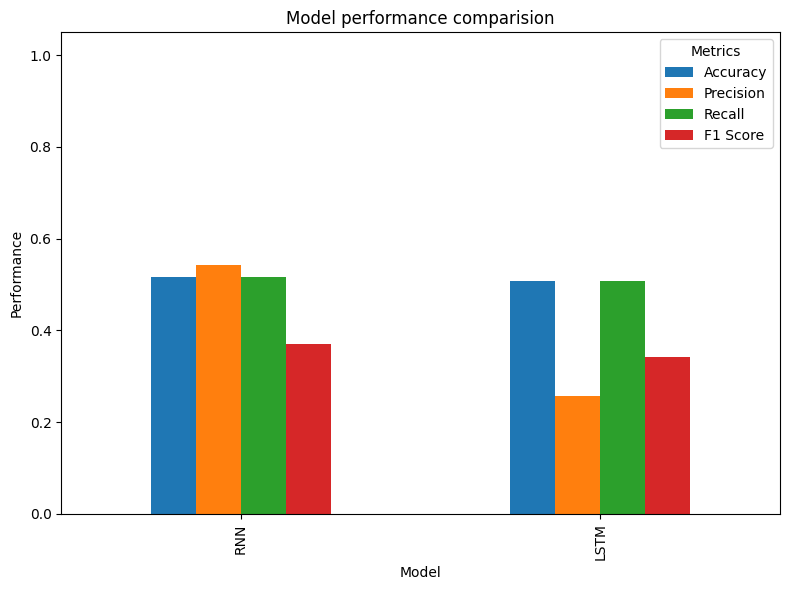

In [ ]:
plot_df=df_comparision_results.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']]

plot_df.plot(kind='bar',figsize=(8,6))

plt.title('Model performance comparision')
plt.xlabel('Model')
plt.ylim(0,1.05)
plt.ylabel('Performance')
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

#EXPERIMENT 5 — DistilBERT
#Cleaned Text
#    ↓
#DistilBERT


In [ ]:
from torch.utils.data import DataLoader
from transformers import DistilBertTokenizer
import torch
from torch.utils.data import Dataset
from torch.optim import AdamW


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification


In [ ]:
X=df['cleaned_text']
y=df['sentiment']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=y
                                              )
le=LabelEncoder()

y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [ ]:
class SentimentDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            str(self.texts.iloc[index]),
            padding="max_length",
            truncation=True,
            max_length=self.max_length
        )

        return {
            "input_ids": torch.tensor(encoding["input_ids"]),
            "attention_mask": torch.tensor(encoding["attention_mask"]),
            "labels": torch.tensor(self.labels[index], dtype=torch.long)
        }

In [ ]:
# Initialize the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Create dataset instances
train_dataset = SentimentDataset(X_train, y_train, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [ ]:
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [ ]:
epochs = 3

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {average_loss:.4f}")

Epoch 1/3, Loss: 0.7197
Epoch 2/3, Loss: 0.4711
Epoch 3/3, Loss: 0.3508


In [ ]:
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
y_pred = []
y_true = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        y_pred.extend(predictions.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7708333333333334
Precision: 0.7599713242961418
Recall: 0.7708333333333334
F1 Score: 0.7594231484528119


In [ ]:
#confusion matrix
cm=confusion_matrix(y_true,y_pred)
cm

array([[ 90,   9,   3],
       [ 18,  10,  12],
       [ 18,   6, 122]])

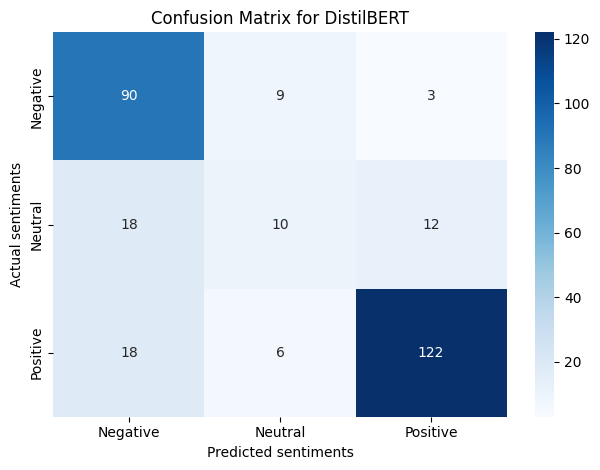

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)
plt.title('Confusion Matrix for DistilBERT')
plt.xlabel('Predicted sentiments')
plt.ylabel('Actual sentiments')
plt.tight_layout()
plt.show()

In [ ]:
all_experiments_data = [
    {
        "Experiment": "Exp 1: TF-IDF",
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, le.transform(y_predict_logistic)),
        "F1 Score": f1_score(
            y_test, le.transform(y_predict_logistic), average="weighted", zero_division=0
        ),
    },
    {
        "Experiment": "Exp 1: TF-IDF",
        "Model": "Multinomial Naive Bayes",
        "Accuracy": accuracy_score(y_test, le.transform(nb_model_pred)),
        "F1 Score": f1_score(
            y_test, le.transform(nb_model_pred), average="weighted", zero_division=0
        ),
    },
    {
        "Experiment": "Exp 1: TF-IDF",
        "Model": "Linear SVM",
        "Accuracy": accuracy_score(y_test, le.transform(y_pred_svm)),
        "F1 Score": f1_score(
            y_test, le.transform(y_pred_svm), average="weighted", zero_division=0
        ),
    },
    # Experiment 2: TF-IDF + Engineered Features
    {
        "Experiment": "Exp 2: TF-IDF + Eng Features",
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, le.transform(lr_y_pred)),
        "F1 Score": f1_score(
            y_test, le.transform(lr_y_pred), average="weighted", zero_division=0
        ),
    },
    {
        "Experiment": "Exp 2: TF-IDF + Eng Features",
        "Model": "Linear SVM",
        "Accuracy": accuracy_score(y_test, le.transform(y_pred_lsvm)),
        "F1 Score": f1_score(
            y_test, le.transform(y_pred_lsvm), average="weighted", zero_division=0
        ),
    },
    # Experiment 3: Word2Vec
    {
        "Experiment": "Exp 3: Word2Vec",
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, le.transform(lr_y_pred_w2v)),
        "F1 Score": f1_score(
            y_test, le.transform(lr_y_pred_w2v), average="weighted", zero_division=0
        ),
    },
     {
        "Experiment": "Exp 3: Word2Vec",
        "Model": "Linear SVM",
        "Accuracy": accuracy_score(y_test, le.transform(y_pred_svm_w2v)),
        "F1 Score": f1_score(
            y_test, le.transform(y_pred_svm_w2v), average="weighted", zero_division=0
        ),
    },
    {
    'Experiment': 'Exp 5: DistilBERT',
         'Model': 'DistilBERT',
         'Accuracy': accuracy_score(y_test, y_pred),
         'F1 Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
     }
]

# 2. Build DataFrame
df_overall_comparison = pd.DataFrame(all_experiments_data)

display(df_overall_comparison)

best_row_idx = df_overall_comparison['F1 Score'].idxmax()
best_model = df_overall_comparison.loc[best_row_idx, "Model"]



print(f" Best model is: {best_model}")

,Experiment,Model,Accuracy,F1 Score
0,Exp 1: TF-IDF,Logistic Regression,0.760417,0.766181
1,Exp 1: TF-IDF,Multinomial Naive Bayes,0.760417,0.701907
2,Exp 1: TF-IDF,Linear SVM,0.795139,0.772485
3,Exp 2: TF-IDF + Eng Features,Logistic Regression,0.708333,0.715510
4,Exp 2: TF-IDF + Eng Features,Linear SVM,0.774306,0.753232
5,Exp 3: Word2Vec,Logistic Regression,0.659722,0.669680
6,Exp 3: Word2Vec,Linear SVM,0.746528,0.695849
7,Exp 5: DistilBERT,DistilBERT,0.770833,0.759423


 Best model is: Linear SVM


## Final Model Selection

Multiple approaches were evaluated for sentiment Analysis, including
TF-IDF-based machine learning models,TF-IDF with Eng Features,Word2Vec-based models, RNN, LSTM,
and DistilBERT.

Although DistilBERT achieved very slight higher performance than the TF-IDF
approach, the improvement was relatively very  small.

Therefore, a TF-IDF-based machine learning model was selected for final
deployment because it provides competitive predictive performance with a
simpler architecture, lower computational cost, faster training,
and easier deployment.

The final TF-IDF classifier was selected based on its F1 Score among the
TF-IDF models is Linear SVM

In [ ]:
import pickle
from pickle import dump
import joblib

# Save the final model and TF-IDF vectorizer using joblib
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Final model saved as:")
print("svm_model.pkl")

print("\nTF-IDF vectorizer saved as:")
print("tfidf_vectorizer.pkl")

Final model saved as:
svm_model.pkl

TF-IDF vectorizer saved as:
tfidf_vectorizer.pkl
